## Paso 2 · Segmentación por densidad

DBSCAN agrupa por densidad local y no necesita que se le diga cuántos grupos
hay: los descubre, y marca como ruido lo que no encaja en ninguno. Eso último
es una ventaja sobre k-means, que fuerza a cada cliente dentro de algún grupo
aunque sea atípico.

El problema es que en alta dimensión las distancias se concentran (todos los
pares terminan casi equidistantes) y la densidad deja de discriminar. Por eso
va primero una reducción a 2D con UMAP.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

from src import config as cfg
from src import data_io, densidad, features, prep, viz

pd.set_option("display.width", 200)
viz.aplicar_estilo()

ruta, origen = data_io.resolver_fuente()
df = data_io.cargar(ruta)
df, _ = prep.limpiar(df)
df = prep.enriquecer(df)
panel = features.construir_panel(df)

# 26 variables: CLR de las 14 participaciones + conducta + intensidad +
# demografía. Las participaciones van en CLR porque suman 1 y la distancia
# euclidiana entre ellas no tiene sentido geométrico sin transformar.
X_scaled, columnas = densidad.construir_matriz(panel)
print(f"Fuente: {origen}  |  X_scaled: {X_scaled.shape[0]} entidades x {X_scaled.shape[1]} variables")

  Sin CSV de Kaggle ni credenciales: se usan datos sinteticos.


Fuente: sintetico  |  X_scaled: 600 entidades x 26 variables


### El embedding

`min_dist=0.0` en lugar del default 0.1: ese default separa puntos
artificialmente para que el mapa se lea mejor, y eso infla los huecos dentro
de un mismo grupo, justo lo que no se quiere antes de un algoritmo de
densidad. `random_state` fijo porque sin él cada corrida mueve los grupos y
ningún `eps` se sostiene entre ejecuciones.

In [2]:
X_2d, _ = densidad.reducir_umap(X_scaled, n_neighbors=15, min_dist=0.0,
                                random_state=cfg.RANDOM_STATE)
densidad.verificar(X_2d, X_scaled).to_frame("valor")

C:\Users\Administrador\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,valor
filas,600
columnas_originales,26
columnas_embedding,2
rango_cp1,-5.25 a 14.83
rango_cp2,-5.79 a 11.16


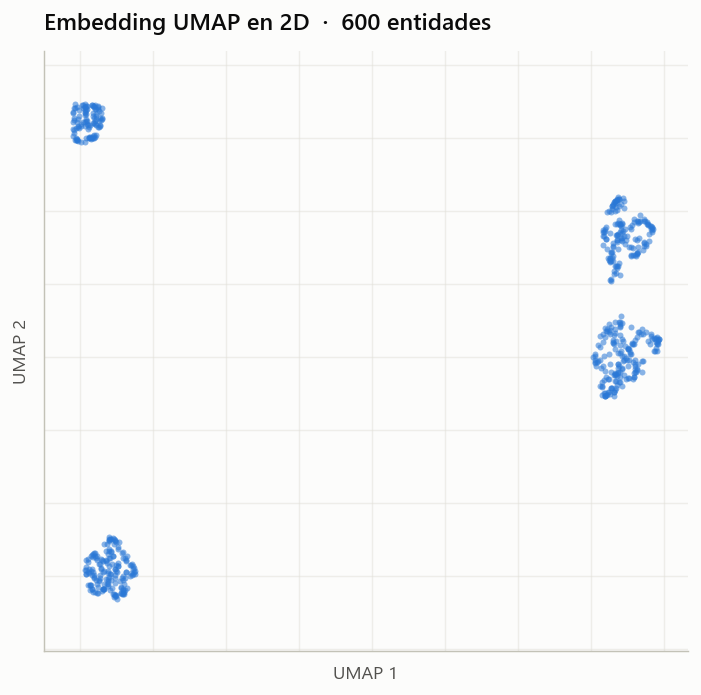

In [3]:
#| label: fig-umap
#| fig-cap: "Las 26 variables del panel reducidas a dos dimensiones con UMAP."
viz.mapa_umap(X_2d)
Image(str(cfg.FIGURES / "07_umap_2d.png"))

### Elegir eps sin adivinar

La curva de k-distancias ordena la distancia de cada punto a su k-ésimo
vecino. La parte plana son los puntos en zonas densas; la subida final, los
aislados. El codo separa ambos regímenes y sugiere el `eps`.

El `k` de la curva tiene que ser el mismo `min_samples` que después recibe
DBSCAN: la curva responde exactamente la pregunta que DBSCAN se hace para
decidir si un punto es núcleo. Con otro `k` describe una densidad distinta de
la que se va a usar.

La regla habitual es `min_samples = 2 × dimensiones`, que sobre un embedding
2D da 4. Acá **no funciona**: con `k=4` el codo cae en un `eps` que parte los
grumos reales en 20 pedazos.

La regla nació pensando en el espacio original de las variables, donde la
dimensión es alta. Después de reducir a 2D conviene otro criterio:
`min_samples` es el **tamaño mínimo de grupo que uno está dispuesto a llamar
grupo**. El barrido recalibra la curva en cada paso, porque cambiar
`min_samples` cambia la densidad que se está midiendo.

In [4]:
# Etiquetas latentes verdaderas, disponibles solo con la fuente sintética.
y_true = None
if "_segmento_real" in df.columns:
    real = df.groupby("cc_num", observed=True)["_segmento_real"].first()
    y_true = panel.index.map(real).to_numpy()

densidad.barrer_min_samples(X_2d, [4, 8, 12, 16, 20, 25, 30], y_true)

,eps_codo,n_grupos,n_ruido,pct_ruido,n_agrupados,ari_agrupados
min_samples,,,,,,
4,0.1767,20,31,5.2,569,0.521
8,0.2641,9,11,1.8,589,0.795
12,0.3407,6,5,0.8,595,0.887
16,0.4153,5,6,1.0,594,0.939
20,0.4906,4,1,0.2,599,0.991
25,0.5853,4,0,0.0,600,0.991
30,0.6628,4,0,0.0,600,0.991


A partir de `min_samples=20` el codo recupera 4 grupos por sí solo. Ese es el
valor que se usa de acá en adelante.

In [5]:
MIN_SAMPLES = densidad.MIN_SAMPLES_DEFAULT   # 20

distancias = densidad.curva_k_distancias(X_2d, MIN_SAMPLES)
i_codo, eps = densidad.codo(distancias)
candidatos = densidad.eps_candidatos(distancias, eps)

print(f"codo en la entidad {i_codo} de {len(distancias)}  ->  eps = {eps:.4f}")
candidatos

codo en la entidad 532 de 600  ->  eps = 0.4906


,factor,eps,pct_no_nucleo
conservador,0.80,0.3925,43.3
codo,1.00,0.4906,11.2
permisivo,1.25,0.6132,2.2


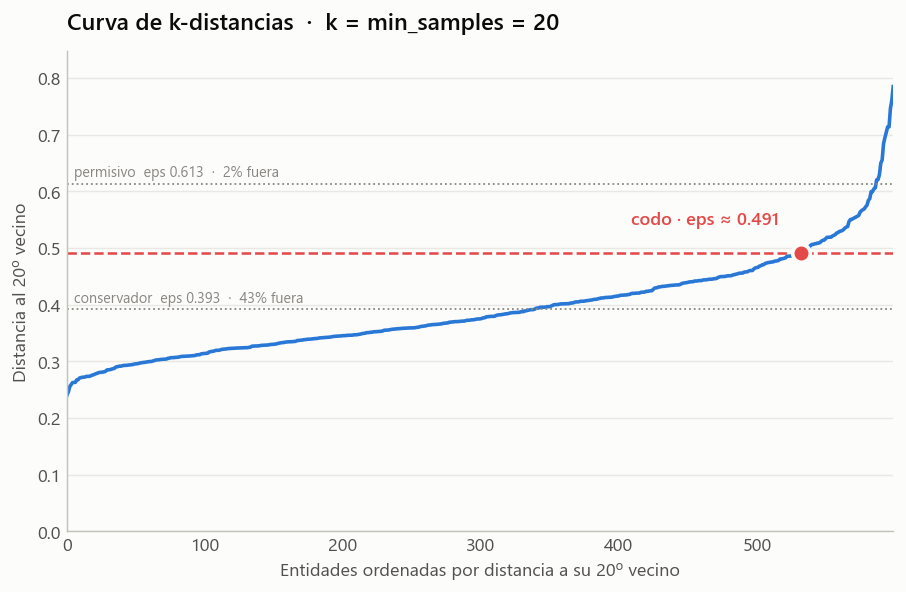

In [6]:
viz.grafico_k_distancias(distancias, i_codo, eps, MIN_SAMPLES, candidatos)
Image(str(cfg.FIGURES / "08_k_distancias.png"))

### DBSCAN

La etiqueta `-1` **no es un grupo**: es la marca de los puntos que no
pertenecen a ninguno. Se cuenta aparte, porque tratarla como un grupo más
mete en el análisis justo los casos que el algoritmo identificó como atípicos.

El índice de Rand ajustado se calcula solo sobre los puntos agrupados, por la
misma razón: el `-1` no es una clase, es la ausencia de clase.

DBSCAN no mide distancia a un centro como k-means: mide **densidad local**.
Con dos parámetros (`eps`, el radio de vecindad, y `min_samples`, cuántos
vecinos hacen falta dentro de ese radio) clasifica cada punto en tres roles.
Un **núcleo** alcanza el mínimo de vecinos; una **frontera** no lo alcanza pero
cae dentro del radio de un núcleo; el **ruido** no cumple ninguna de las dos.
Un grupo es una cadena de núcleos que se alcanzan entre sí, y por eso el número
de grupos no se fija: sale de la geometría.

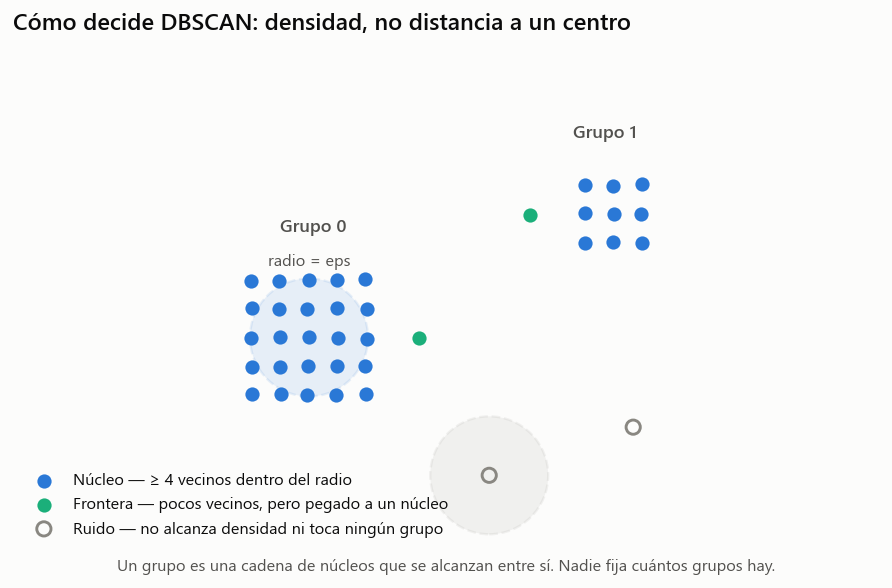

In [7]:
#| label: fig-como-agrupa
#| fig-cap: "Los tres roles que asigna DBSCAN. Los puntos son ilustrativos, pero la clasificación la calcula el algoritmo real."
viz.diagrama_dbscan()
Image(str(cfg.FIGURES / "10_como_agrupa_dbscan.png"))

In [8]:
densidad.comparar_eps(X_2d, candidatos["eps"], MIN_SAMPLES, y_true)

,eps,n_grupos,n_agrupados,n_ruido,pct_ruido,ari_agrupados
0,0.3925,7,578,22,3.7,0.846
1,0.4906,4,599,1,0.2,0.991
2,0.6132,4,600,0,0.0,0.991


In [9]:
etiquetas = densidad.agrupar(X_2d, eps=eps, min_samples=MIN_SAMPLES)

resumen = densidad.resumen_grupos(etiquetas)
print(f"Grupos detectados (excluyendo -1): {resumen['n_grupos']}")
print(f"Puntos de ruido (-1)             : {resumen['n_ruido']}  "
      f"({resumen['pct_ruido']}%)")

densidad.tamanos_grupos(etiquetas)

Grupos detectados (excluyendo -1): 4
Puntos de ruido (-1)             : 1  (0.2%)


,entidades,pct
ruido (-1),1,0.2
grupo 0,150,25.0
grupo 1,175,29.2
grupo 2,106,17.7
grupo 3,168,28.0


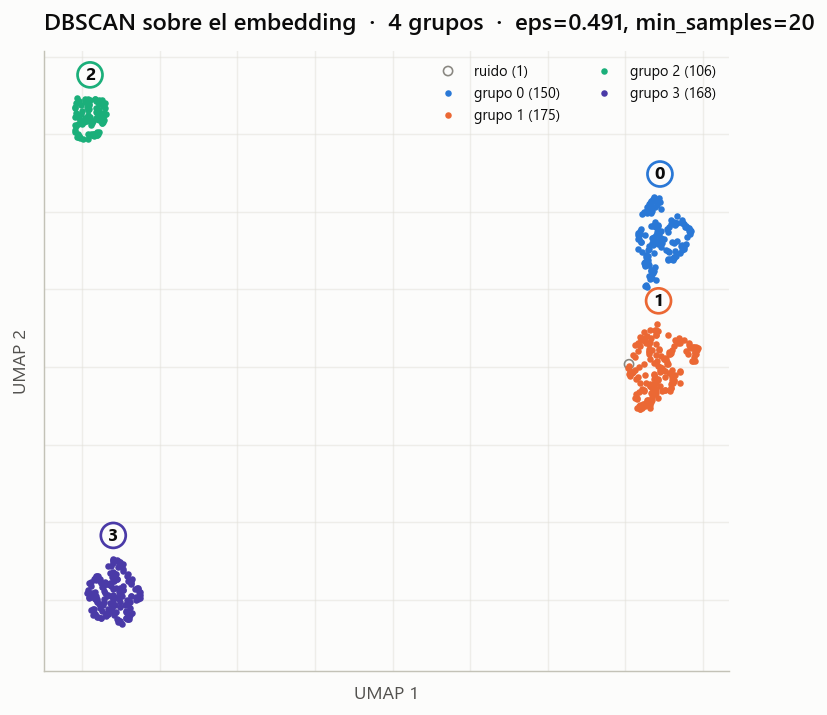

In [10]:
#| label: fig-dbscan
#| fig-cap: "Grupos hallados por DBSCAN. El ruido va hueco y en gris."
viz.mapa_clusters(X_2d, etiquetas, eps, MIN_SAMPLES)
Image(str(cfg.FIGURES / "09_dbscan.png"))

### Los grupos encontrados

DBSCAN devuelve identificadores (0, 1, 2, 3), no nombres. Las etiquetas de la
tabla son una lectura del perfil de cada grupo, y se pueden verificar contra
las columnas: son interpretación del analista, no salida del algoritmo.

In [11]:
#| label: tbl-grupos
#| tbl-cap: "Perfil de los grupos hallados por DBSCAN. El ruido va como fila aparte."
# Sin esto pandas corta "Categorías principales" con puntos suspensivos.
with pd.option_context("display.max_colwidth", None):
    display(densidad.perfilar_grupos(panel, etiquetas, densidad.NOMBRES_GRUPOS))

,Clientes,% clientes,% facturación,Gasto mensual,Ticket medio,Edad media,% hedónico,% online,% nocturno,Categorías principales
Segmento,,,,,,,,,,
Rutina de mantenimiento,150,25.0,12.9,422,39,68,15,6,6,Supermercado (presencial) · Salud y bienestar · Hogar
Hogar con dependientes,175,29.2,25.6,717,65,43,25,5,7,Supermercado (presencial) · Hogar · Ninos y mascotas
Alto valor experiencial,106,17.7,43.3,2001,184,49,91,11,19,Viajes · Compras (presencial) · Compras (online)
Digital joven,168,28.0,18.0,526,48,28,68,52,15,Compras (online) · Entretenimiento · Varios (online)
Atípicos,1,0.2,0.1,710,69,41,29,3,6,Hogar · Compras (presencial) · Supermercado (presencial)


### Qué tan bien salió

Con la fuente sintética hay 4 segmentos latentes conocidos, así que la
partición se puede auditar en vez de solo mirarla.

In [12]:
if y_true is not None:
    cruce = pd.crosstab(pd.Series(y_true, name="segmento latente"),
                        pd.Series(etiquetas, name="grupo DBSCAN"))
    display(cruce)

grupo DBSCAN,-1,0,1,2,3
segmento latente,,,,,
conservadores_maduros,0,149,1,0,0
digitales_urbanos,0,0,0,0,168
familias_suburbanas,1,1,174,0,0
viajeros_alto_gasto,0,0,0,106,0


### Los atípicos

Los puntos con etiqueta `-1` no se descartan: son entidades con un perfil tan
singular que no entraron en ninguna región densa, y en la práctica suelen ser
los casos más informativos del análisis.

La configuración elegida deja **un solo** atípico. Es buena señal para la
segmentación (los grupos son limpios), pero con n=1 no hay promedio que
comparar. Para caracterizar el perfil se usa el `eps` conservador, que exige
más densidad y por lo tanto marca más casos como atípicos.

In [13]:
# Se separan, no se eliminan. El orden de labels coincide con el del panel.
mi_df_outliers, mi_df_resto = densidad.separar_outliers(panel, etiquetas)

# Verificación: la cantidad de filas tiene que coincidir con la de etiquetas -1.
print(f"etiquetas == -1     : {(etiquetas == -1).sum()}")
print(f"filas en outliers   : {len(mi_df_outliers)}")
print(f"coinciden           : {(etiquetas == -1).sum() == len(mi_df_outliers)}")

etiquetas == -1     : 1
filas en outliers   : 1
coinciden           : True


In [14]:
# eps conservador: más exigente en densidad, así que marca más atípicos.
eps_cons = candidatos.loc["conservador", "eps"]
etiquetas_cons = densidad.agrupar(X_2d, eps=eps_cons, min_samples=MIN_SAMPLES)

mi_df_outliers, mi_df_resto = densidad.separar_outliers(panel, etiquetas_cons)
print(f"eps={eps_cons:.4f}  ->  {len(mi_df_outliers)} atípicos de {len(panel)}")

eps=0.3925  ->  22 atípicos de 600


In [15]:
#| label: tbl-outliers
#| tbl-cap: "Atípicos frente al resto de la cartera."
# La comparación va sobre las variables del panel original, no sobre las
# coordenadas UMAP: el embedding sirvió para encontrarlos, no para describirlos.
densidad.perfil_outliers(panel, etiquetas_cons).head(8).round(3)

,Atípicos,Resto,Brecha (desv. est.),Brecha %,Percentil medio
Variable,,,,,
% gasto utilitario,0.704,0.456,0.806,54.450,65.083
% nocturno,0.069,0.113,-0.738,-38.592,33.057
% gasto hedónico,0.249,0.471,-0.727,-47.247,36.924
% gasto en línea,0.069,0.199,-0.607,-65.369,36.326
Tamaño de ciudad (log),8.832,10.062,-0.604,-12.226,31.962
Diversificación de la canasta,0.848,0.804,0.558,5.423,71.515
Volatilidad del gasto mensual,0.436,0.393,0.476,10.967,56.803
% en montos redondos,0.139,0.122,0.400,13.771,60.057


Los atípicos son marcadamente **utilitarios**: gastan más en categorías de
necesidad y bastante menos de noche, en línea y en categorías hedónicas, y
viven en ciudades más chicas. Un perfil coherente, no un revoltijo.

Pero la columna `percentil_medio` obliga a matizar la lectura: se mueve entre
32 y 72, o sea que **estos casos no son extremos en ninguna variable**. Si
fueran el cliente de máximo valor o un fraude, estarían pegados al percentil 99
o al 1. Lo que DBSCAN encontró acá son casos *fronterizos*: clientes en el
valle entre dos grupos, no en la cola de la distribución.

Es una distinción que decide qué hacer con ellos. Un extremo se investiga caso
por caso: puede ser error de captura o la cuenta más rentable de la cartera.
Un fronterizo casi nunca es error: es alguien cuyo perfil mezcla dos segmentos,
y lo accionable es preguntarse si el esquema de segmentación necesita un grupo
más, no revisarle la ficha.

In [16]:
# Para la revisión caso por caso: las filas completas, no un promedio.
COLS_REVISION = ["gasto_por_mes", "ticket_medio", "txn_por_mes", "edad",
                 "share_utilitario", "share_hedonico", "share_online",
                 "diversificacion", "state", "job"]
mi_df_outliers[COLS_REVISION].round(3).head(10)

,gasto_por_mes,ticket_medio,txn_por_mes,edad,share_utilitario,share_hedonico,share_online,diversificacion,state,job
cc_num,,,,,,,,,,
4000000000174218,380.056,34.812,10.917,69.786,0.808,0.076,0.067,0.814,NY,Chef
4000000000261327,553.845,66.154,8.372,47.860,0.719,0.234,0.022,0.825,TX,Architect
4000000000593925,874.774,65.906,13.273,40.866,0.753,0.231,0.044,0.855,FL,Sales manager
4000000000601844,710.345,69.143,10.274,41.394,0.654,0.290,0.027,0.867,NC,Journalist
4000000001187850,326.092,45.948,7.097,65.751,0.700,0.276,0.112,0.864,MI,Financial analyst
4000000001346230,414.074,67.460,6.138,51.792,0.669,0.318,0.095,0.820,PA,Architect
4000000001686747,281.069,38.545,7.292,56.591,0.738,0.182,0.049,0.858,NY,Pharmacist
4000000001868884,828.545,66.221,12.512,39.923,0.694,0.294,0.044,0.841,CA,Teacher
4000000002177725,530.652,65.238,8.134,40.051,0.603,0.318,0.124,0.868,NY,Truck driver


Dos advertencias para no sobreleer el resultado.

El embedding 2D **distorsiona la densidad**. UMAP optimiza la topología local,
no las distancias, así que la separación entre grupos en el mapa no es
proporcional a su disimilitud real, y una proyección a 2D puede tanto
fabricar grupos como disolverlos. Acá se pudo verificar contra la verdad
conocida; con datos reales esa red de seguridad no existe.

Y las coordenadas UMAP no son interpretables: no tienen unidades ni
significado individual, por eso el gráfico va sin números en los ejes. Sirven
para *encontrar* los grupos; para describirlos hay que volver a las
participaciones y a la demografía del panel original.